## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [16]:
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [17]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [18]:
df = df.drop(columns=['Customer ID']).copy()
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [19]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [20]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [21]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [22]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [23]:
male_df = df[df['Gender'] == 'Male'].copy()
female_df = df[df['Gender'] == 'Female'].copy()
print('Male:', male_df.shape)
print('Female:', female_df.shape)

Male: (2652, 18)
Female: (1248, 18)


## **EDA**

### **Item Purchased**

In [24]:
top_item_all = df['Item Purchased'].value_counts().reset_index()
top_item_all.columns = ['Item Purchased', 'count']
top_item_m = male_df['Item Purchased'].value_counts().reset_index()
top_item_m.columns = ['Item Purchased', 'count']
top_item_f = female_df['Item Purchased'].value_counts().reset_index()
top_item_f.columns = ['Item Purchased', 'count']
top_item_all.head(10)

,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


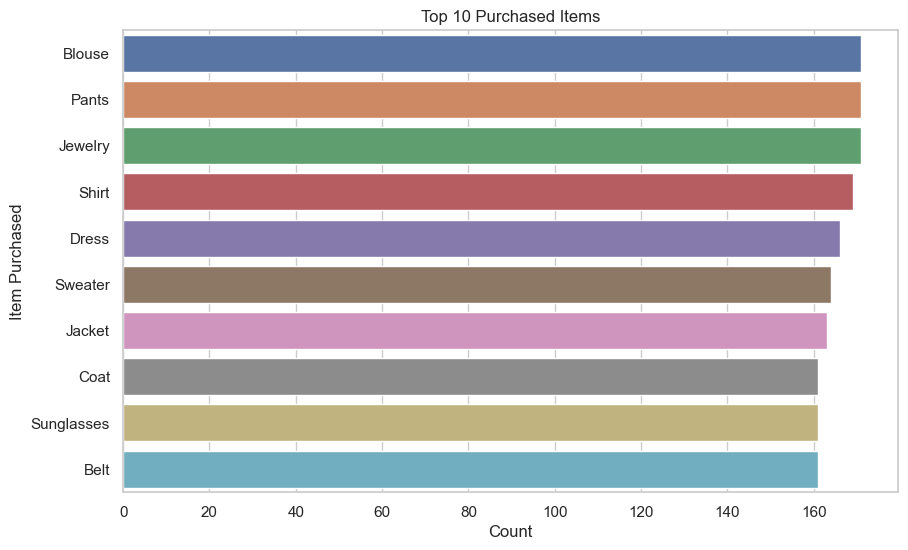

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_item_all.head(10), y='Item Purchased', x='count', hue='Item Purchased', dodge=False, legend=False)
plt.title('Top 10 Purchased Items')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

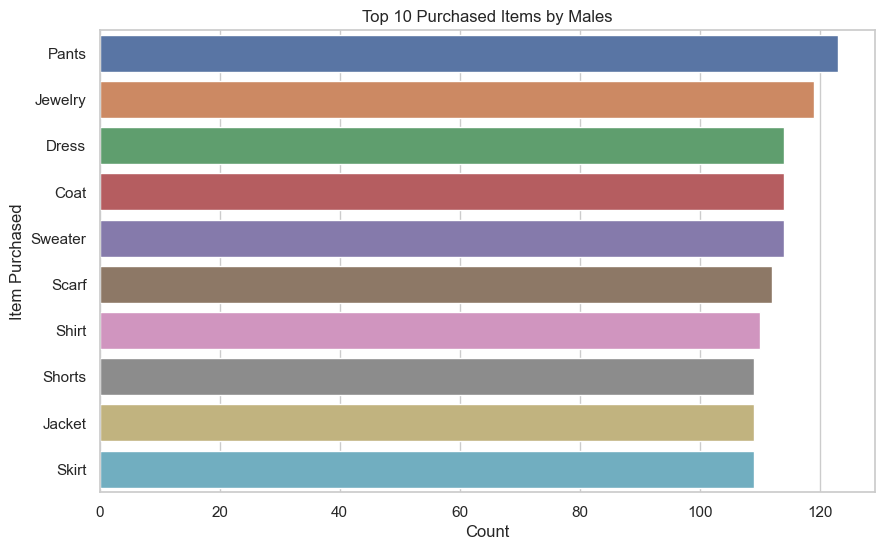

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_item_m.head(10), y='Item Purchased', x='count', hue='Item Purchased', dodge=False, legend=False)
plt.title('Top 10 Purchased Items by Males')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

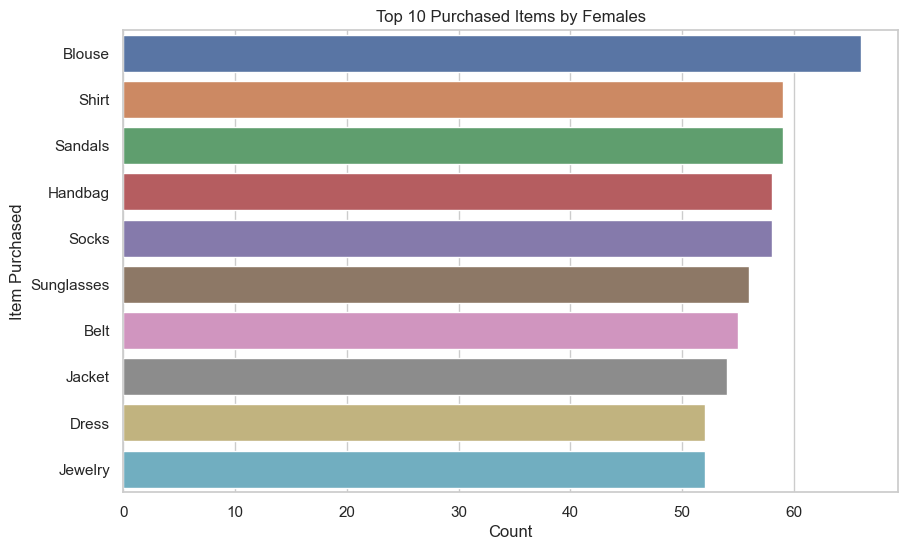

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_item_f.head(10), y='Item Purchased', x='count', hue='Item Purchased', dodge=False, legend=False)
plt.title('Top 10 Purchased Items by Females')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [28]:
size_all = df['Size'].value_counts().reset_index()
size_all.columns = ['Size', 'count']
size_all

,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [29]:
size_m = male_df['Size'].value_counts()
size_f = female_df['Size'].value_counts()
pd.DataFrame({'Male': size_m, 'Female': size_f}).fillna(0).astype(int)

,Male,Female
Size,,
M,1165,590
L,716,337
S,476,187
XL,295,134


### **Category**

In [30]:
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'count']
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [31]:
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_m.columns = ['Category', 'count']
ctg_f = female_df['Category'].value_counts().reset_index()
ctg_f.columns = ['Category', 'count']
ctg_m, ctg_f

(      Category  count
 0     Clothing   1181
 1  Accessories    848
 2     Footwear    400
 3    Outerwear    223,
       Category  count
 0     Clothing    556
 1  Accessories    392
 2     Footwear    199
 3    Outerwear    101)

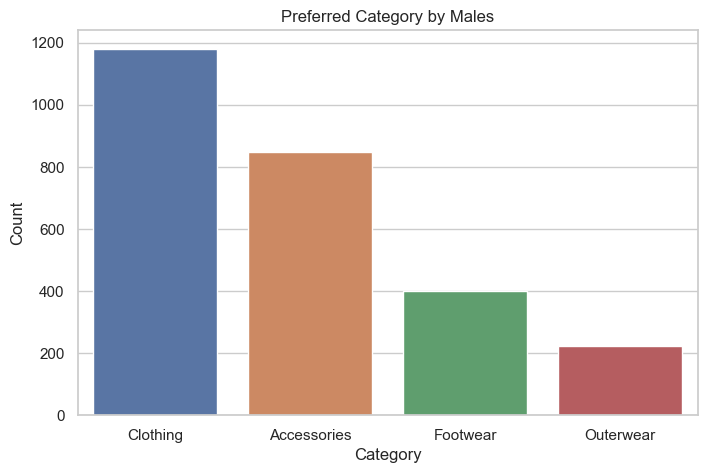

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg_m, x='Category', y='count', hue='Category', dodge=False, legend=False)
plt.title('Preferred Category by Males')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

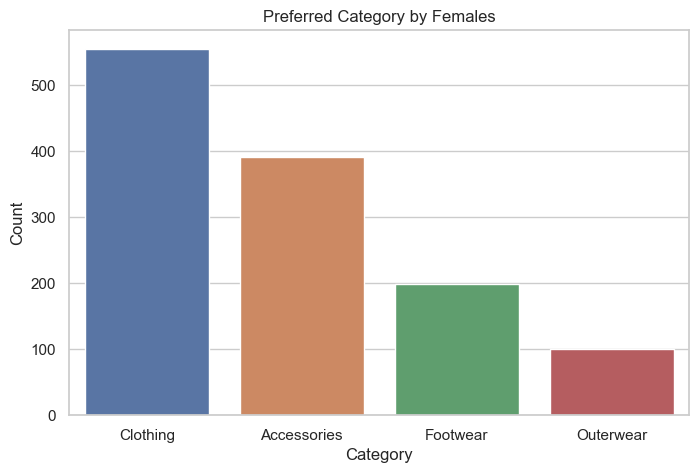

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg_f, x='Category', y='count', hue='Category', dodge=False, legend=False)
plt.title('Preferred Category by Females')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

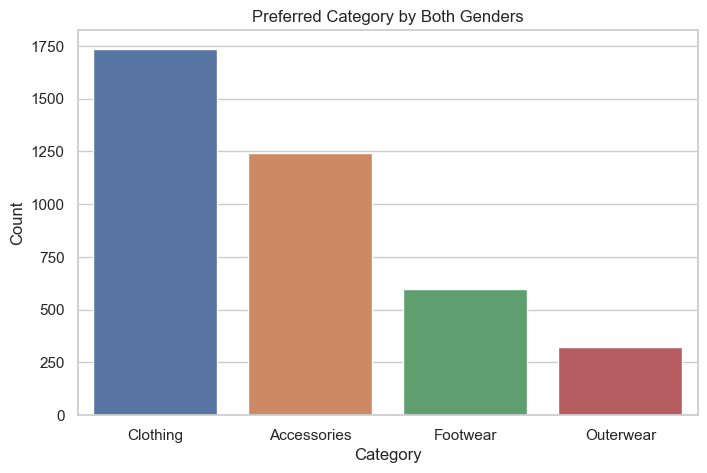

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ctg, x='Category', y='count', hue='Category', dodge=False, legend=False)
plt.title('Preferred Category by Both Genders')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [35]:
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())
waffle_data_m, waffle_data_f

({'Clothing': np.int64(1181),
  'Accessories': np.int64(848),
  'Footwear': np.int64(400),
  'Outerwear': np.int64(223)},
 {'Clothing': np.int64(556),
  'Accessories': np.int64(392),
  'Footwear': np.int64(199),
  'Outerwear': np.int64(101)})

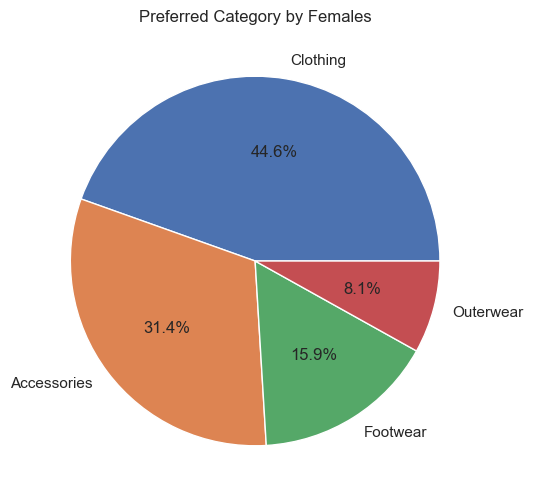

In [36]:
plt.figure(figsize=(6, 6))
plt.pie(waffle_data_f.values(), labels=waffle_data_f.keys(), autopct='%1.1f%%')
plt.title('Preferred Category by Females')
plt.show()

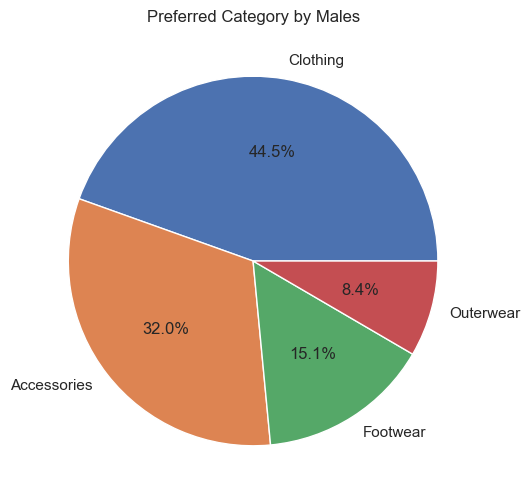

In [37]:
plt.figure(figsize=(6, 6))
plt.pie(waffle_data_m.values(), labels=waffle_data_m.keys(), autopct='%1.1f%%')
plt.title('Preferred Category by Males')
plt.show()

### **Review ratings**

In [38]:
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
avg_cr_f

np.float64(3.7044964028776977)

In [39]:
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
avg_cr_m

np.float64(3.7319220999153258)

In [40]:
avg_cr_m, avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

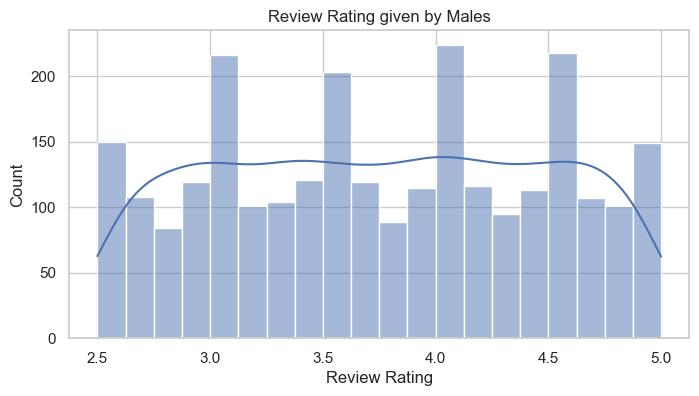

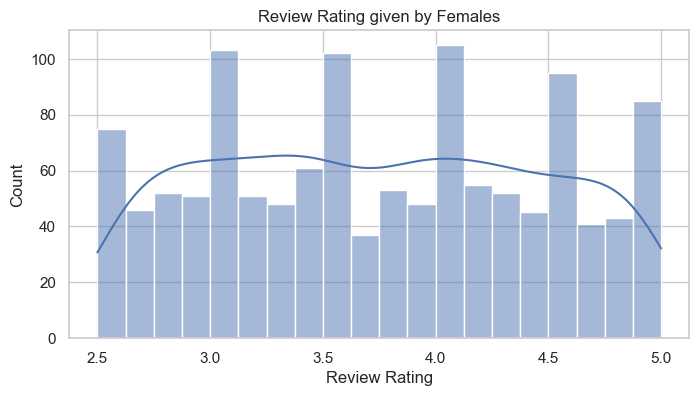

In [41]:
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20, kde=True)
plt.title('Review Rating given by Males')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20, kde=True)
plt.title('Review Rating given by Females')
plt.show()

In [42]:
cr_m['Review Rating'].value_counts().sort_index()

Review Rating
2.5    17
2.6    45
2.7    55
2.8    41
2.9    55
3.0    49
3.1    46
3.2    41
3.3    49
3.4    59
3.5    48
3.6    46
3.7    61
3.8    39
3.9    52
4.0    52
4.1    48
4.2    52
4.3    45
4.4    43
4.5    36
4.6    46
4.7    46
4.8    46
4.9    48
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [43]:
m_tpa = male_df['Purchase Amount (USD)'].sum()
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(f'Male total: {m_tpa:,.0f} USD')
print(f'Female total: {f_tpa:,.0f} USD')

Male total: 157,890 USD
Female total: 75,191 USD


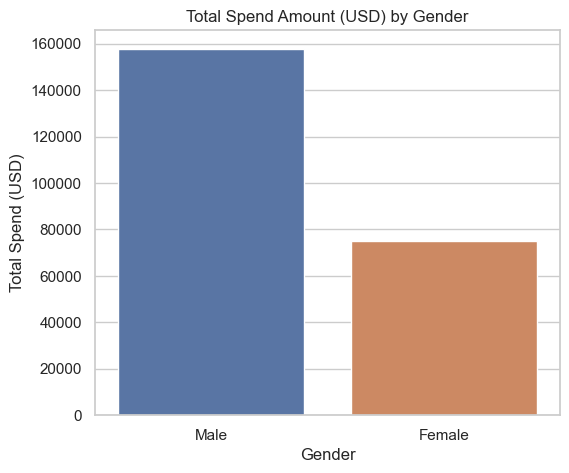

In [45]:
spend_by_gender = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend': [m_tpa, f_tpa]
})
plt.figure(figsize=(6, 5))
sns.barplot(data=spend_by_gender, x='Gender', y='Total Spend', hue='Gender', dodge=False, legend=False)
plt.title('Total Spend Amount (USD) by Gender')
plt.ylabel('Total Spend (USD)')
plt.show()

In [46]:
cc_f = female_df[female_df['Category'] == 'Clothing']
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']
[f.shape[0] for f in [cc_f, ca_f, cf_f, co_f]]

[556, 392, 199, 101]

In [47]:
cc_m = male_df[male_df['Category'] == 'Clothing']
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']
[m.shape[0] for m in [cc_m, ca_m, cf_m, co_m]]

[1181, 848, 400, 223]

In [48]:
pcu = df['Promo Code Used'].value_counts().to_dict()
pcu

{'No': 2223, 'Yes': 1677}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

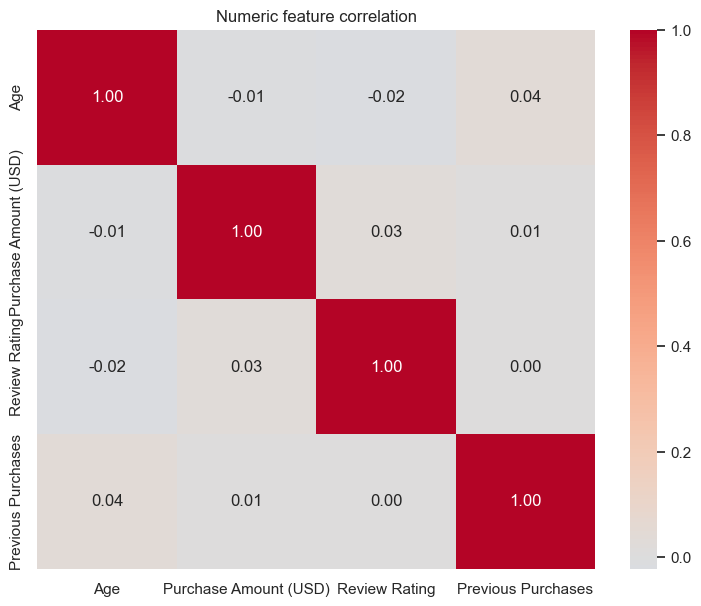

In [49]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric feature correlation')
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [50]:
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [51]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

amount_scaler = MinMaxScaler()
age_scaler = StandardScaler()
df['Amount_minmax'] = amount_scaler.fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = age_scaler.fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [52]:
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[-np.inf, 40, 70, np.inf],
    labels=['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
High      1447
Medium    1393
Low       1060
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.